# Digital Twin — Pipeline Lengkap
## Simulated Telemetry → Benchmark DP → Strategi GA → Driving Line

#### Tentang notebook ini

Lapisan presentasi tipis di atas package `digital_twin/` — semua logika fisika/optimasi ada di package, notebook ini hanya memanggil fungsinya dan menampilkan hasil.

**Isi pipeline:**
1. Skenario cuaca (climate normals Januari, 3 skenario)
2. Profil track terpadu (elevasi, grade, tikungan, **lebar terukur per titik** dari digitasi satelit)
3. Simulasi crude (constant-speed + powertrain nyata) → simulated telemetry
4. Visualisasi telemetri
5. Benchmark DP — batas atas efisiensi fisik (pulse-and-glide muncul sendiri)
6. Strategi GA — versi driver-executable (dimuat dari hasil run terpisah)
7. Driving line optimal (shortest-path QP) & dampaknya
8. Ringkasan

Setiap konstanta ditag tingkat kepercayaannya di `digital_twin/config.py` (MEASURED / RULE-DERIVED / PLACEHOLDER). **Massa kendaraan ter-update: 88 kg (+3 kg, 2026-07-17) → total 158 kg** — hasil simulasi lama yang dihitung dengan 155 kg perlu di-rerun untuk angka final.

**Update (2026-07-21) -- outputs below are STALE, re-run the notebook to refresh:**
- `config.DEFAULT_FC_NAME` is now `"SZFC-1000"` (real SENZA 1000W fuel cell stack the
  team is using -- digitized from `SZFC-1000.pdf`, replaces the old `"G-HFCS 600W
  24V"` placeholder). Every cell below already reads `config.DEFAULT_FC_NAME`
  dynamically, so nothing in the code needs changing -- just re-execute.
- `optimize_ga.py`/`optimize_pso.py`/`optimize_cma.py` now default to the real
  **two-motor** powertrain (`ACCEL_MOTOR_NAME="BLDC 650W"` for launches/climbs,
  `CRUISE_MOTOR_NAME="BG 42x30 dCore"` otherwise, `"rule"` mode -- the
  hardware-achievable switching logic, not the analysis-only efficiency ceiling).
  Section 3's crude milestone and Section 5's DP benchmark still intentionally use
  the single `DEFAULT_MOTOR_NAME` reference motor (Innotec) -- DP stays a
  single-motor physics ceiling by design (see
  `notebooks/Racing_Line_Strategy_Comparison.ipynb` for why); only Section 6's GA
  numbers (loaded from `data/simulated_telemetry_ga.csv`) reflect the two-motor
  config once that file is regenerated.

In [1]:
import os, sys

# digital_twin package dan semua path data ("data/...") ditulis relatif terhadap root repo,
# bukan folder notebooks/ -- pindah working directory dulu kalau perlu.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print("Working directory:", os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from digital_twin import config
from digital_twin import weather as weather_mod
from digital_twin import track as track_mod
from digital_twin import vehicle
from digital_twin import simulate as sim_mod

%matplotlib inline

Working directory: /Users/elyne/FP-Internship-B


#### 1. Skenario cuaca\n\nKarena tanggal lomba (2027-01-10) masih ~1.5 tahun lagi, tidak ada forecast asli yang bisa dipakai -- yang ada cuma climate normals Januari untuk Doha/Lusail (angin dominan NW/NNW, \"winter Shamal\"). Dibungkus jadi 3 skenario bernama supaya strategi nanti diuji robust di rentang yang masuk akal, bukan dituning ke satu tebakan.

In [2]:
rows = []
for name, sc in weather_mod.SCENARIOS.items():
    rows.append({
        "scenario": sc.name,
        "temp_C": sc.temperature_c,
        "RH_%": sc.relative_humidity * 100,
        "pressure_hPa": sc.pressure_hpa,
        "wind_kmh": sc.wind_speed_kmh,
        "wind_from_deg": sc.wind_from_bearing_deg,
        "air_density_kg_m3": round(weather_mod.air_density(sc), 4),
    })
weather_df = pd.DataFrame(rows)
weather_df

,scenario,temp_C,RH_%,pressure_hPa,wind_kmh,wind_from_deg,air_density_kg_m3
0,calm,17.5,65.0,1015.0,9.0,351.0,1.2107
1,typical_january,17.7,65.0,1015.0,17.0,351.0,1.2098
2,shamal_strong,14.0,50.0,1018.0,28.0,351.0,1.2314


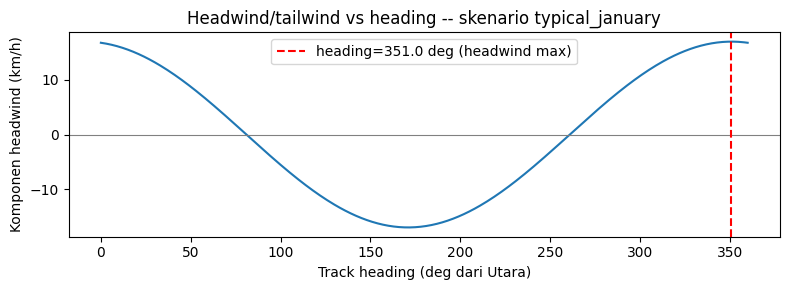

In [3]:
# Sanity check: komponen headwind/tailwind harus memuncak persis di arah yang benar secara geometri
sc = weather_mod.WEATHER_TYPICAL_JAN
headings = np.linspace(0, 360, 361)
headwind = [weather_mod.headwind_component_kmh(sc, h) for h in headings]

plt.figure(figsize=(8, 3))
plt.plot(headings, headwind)
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(sc.wind_from_bearing_deg, color="red", linestyle="--", label=f"heading={sc.wind_from_bearing_deg} deg (headwind max)")
plt.xlabel("Track heading (deg dari Utara)")
plt.ylabel("Komponen headwind (km/h)")
plt.title(f"Headwind/tailwind vs heading -- skenario {sc.name}")
plt.legend()
plt.tight_layout()
plt.show()

#### 2. Profil track terpadu\n\nMenggabungkan data GPS/elevasi mentah (per ~1m) dengan tabel tikungan yang sudah dihitung sebelumnya (`SEM_APME2025_Track_Analysis.ipynb`) -- ini mengisi celah yang teridentifikasi di rencana: `track_analysis_final.csv` itu ringkasan hasil transkrip manual, bukan tabel per-titik yang bisa dipakai simulator.

In [4]:
profile = track_mod.build_track_profile(save=True)
print(f"{len(profile)} titik, {(profile['zone_type']=='turn').sum()} di zona tikungan, "
      f"{profile['stop_event'].sum()} flag lokasi stop")
profile.head()

3677 titik, 1359 di zona tikungan, 2 flag lokasi stop


,Id,latitude,longitude,altitude_m,distance_km,distance_m,heading_deg,grade_pct,zone_type,zone_id,r_min_m,v_safe_kmh,stop_event,width_m,w_left_m,w_right_m,centerline_shift_m
0,0,25.488420,51.450170,11.7,0.000,0.0,334.427095,-0.262376,straight,-1,inf,inf,True,16.70,8.508333,8.191667,2.591667
1,1,25.488428,51.450166,11.7,0.001,1.0,332.518135,-0.278171,straight,-1,inf,inf,False,16.70,8.508333,8.191667,2.591667
2,2,25.488436,51.450161,11.7,0.002,2.0,330.944386,-0.297030,straight,-1,inf,inf,False,16.65,8.368750,8.281250,2.531250
3,3,25.488444,51.450156,11.7,0.003,3.0,329.338346,-0.314249,straight,-1,inf,inf,False,16.65,8.368750,8.281250,2.531250
4,4,25.488452,51.450151,11.7,0.004,4.0,328.371684,-0.330033,straight,-1,inf,inf,False,16.65,8.368750,8.281250,2.531250


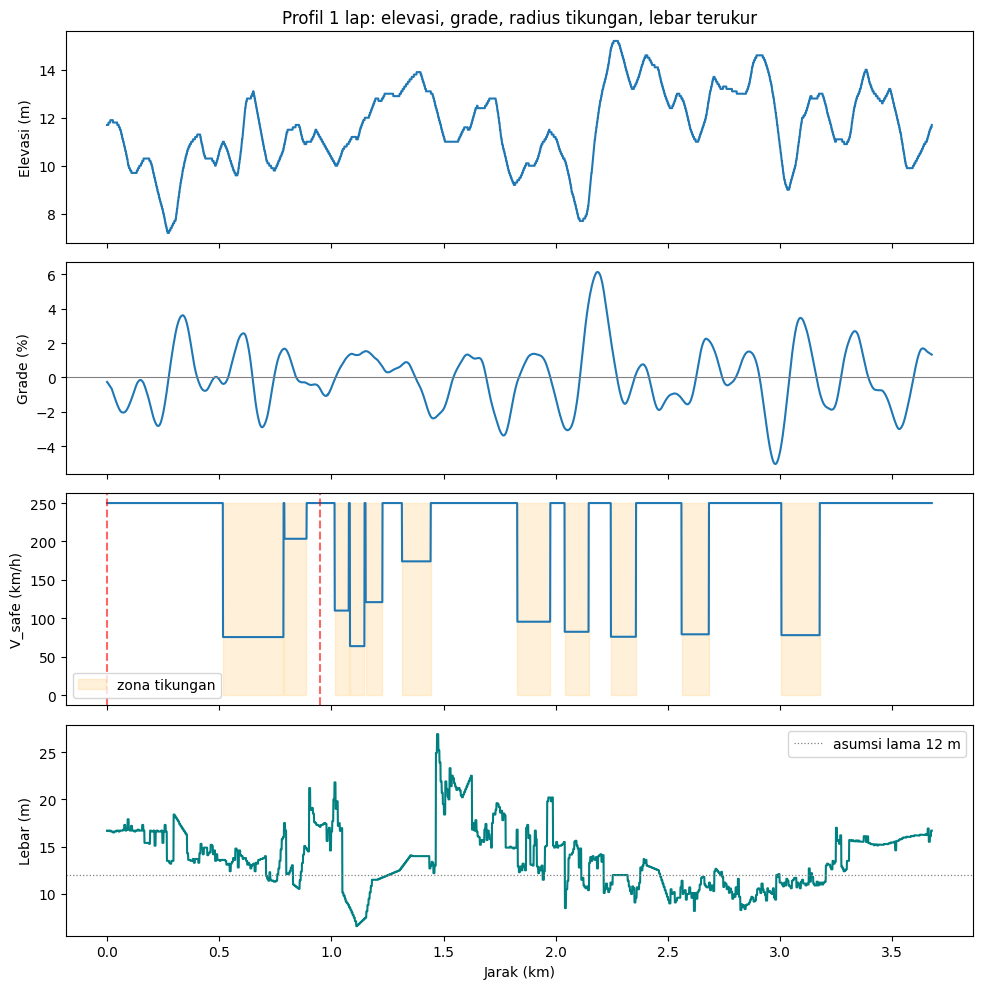

Lebar terukur: min 6.6 / median 13.6 / max 26.9 m


In [5]:
fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

axes[0].plot(profile["distance_km"], profile["altitude_m"])
axes[0].set_ylabel("Elevasi (m)")
axes[0].set_title("Profil 1 lap: elevasi, grade, radius tikungan, lebar terukur")

axes[1].plot(profile["distance_km"], profile["grade_pct"])
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].set_ylabel("Grade (%)")

turn_mask = profile["zone_type"] == "turn"
axes[2].plot(profile["distance_km"], profile["v_safe_kmh"].clip(upper=250))
axes[2].fill_between(profile["distance_km"], 0, 250, where=turn_mask, alpha=0.15, color="orange", label="zona tikungan")
for stop_km in config.STOP_LOCATIONS_KM:
    axes[2].axvline(stop_km, color="red", linestyle="--", alpha=0.6)
axes[2].set_ylabel("V_safe (km/h)")
axes[2].legend()

# Lebar drivable per titik (digitasi citra satelit -- lihat Track_Analysis Bagian 7)
axes[3].plot(profile["distance_km"], profile["width_m"], color="teal")
axes[3].axhline(12.0, color="gray", linestyle=":", linewidth=0.9, label="asumsi lama 12 m")
axes[3].set_ylabel("Lebar (m)")
axes[3].set_xlabel("Jarak (km)")
axes[3].legend()

plt.tight_layout()
plt.show()

print(f"Lebar terukur: min {profile['width_m'].min():.1f} / median {profile['width_m'].median():.1f} / "
      f"max {profile['width_m'].max():.1f} m")

## 3. Jalankan simulasi crude (powertrain nyata)\n\nStrategi: coba pertahankan kecepatan cruise target, melambat sebelum tikungan/stop kalau perlu (dihitung mundur supaya pengereman yang dibutuhkan selalu fisis, tidak instan). **Update:** powertrain sekarang pakai kurva motor/FC nyata (bukan lagi ideal daya tak terbatas), plus koreksi konservatif: parasitic load FC (Pasal 65), rugi thermal buffer, cornering scrub drag, dan lokasi stop dari koordinat GPS asli (bukan tebakan tengah-lurusan lagi). Skor akhir juga sudah menggabungkan H2 flow-meter + ekuivalen baterai aksesori (joulemeter, Pasal 54e) -- strategi ini masih heuristik sederhana, BUKAN hasil optimasi (itu bagian DP/GA di bawah).

In [6]:
from digital_twin import powertrain, telemetry as telemetry_mod

motor = powertrain.load_motors()[config.DEFAULT_MOTOR_NAME]
fc = powertrain.load_fuel_cells()[config.DEFAULT_FC_NAME]

telemetry = sim_mod.run_crude_milestone(scenario_name="typical_january", save=True)

total_time_s = telemetry["t_s"].iloc[-1]
total_dist_km = telemetry["s_m"].iloc[-1] / 1000.0
avg_speed_kmh = total_dist_km / (total_time_s / 3600.0)
max_speed_kmh = telemetry["v_kmh"].max()
total_h2_m3 = telemetry["h2_cumulative_m3"].iloc[-1]
total_accessory_j = telemetry["accessory_energy_cumulative_j"].iloc[-1]
accessory_h2_equiv_l = telemetry_mod.accessory_h2_equivalent_m3(total_accessory_j) * 1000
h2_score = telemetry_mod.h2_score_km_per_m3(total_dist_km, total_h2_m3, accessory_energy_j=total_accessory_j)

summary = pd.DataFrame([
    {"metrik": "Motor", "nilai": config.DEFAULT_MOTOR_NAME},
    {"metrik": "Fuel cell", "nilai": config.DEFAULT_FC_NAME},
    {"metrik": "Total jarak (km)", "nilai": round(total_dist_km, 3), "syarat_aturan": config.TOTAL_DISTANCE_KM},
    {"metrik": "Total waktu (menit)", "nilai": round(total_time_s / 60, 2), "syarat_aturan": f"maks {config.MAX_ATTEMPT_TIME_MIN}"},
    {"metrik": "Kecepatan rata-rata (km/h)", "nilai": round(avg_speed_kmh, 2), "syarat_aturan": f"min {config.V_TARGET_AVG_KMH_MIN:.2f}"},
    {"metrik": "H2 flow-meter (L, incl. parasitic FC)", "nilai": round(total_h2_m3 * 1000, 2)},
    {"metrik": "Baterai aksesori (kJ, excl. horn)", "nilai": round(total_accessory_j / 1000, 1)},
    {"metrik": "H2-ekuivalen aksesori (L)", "nilai": round(accessory_h2_equiv_l, 2)},
    {"metrik": "Skor bersih Pasal 54e (km/m3 H2)", "nilai": round(h2_score, 1)},
    {"metrik": "Pelanggaran V_safe", "nilai": int(telemetry["rule_violation"].sum()), "syarat_aturan": 0},
    {"metrik": "Jumlah stop event", "nilai": int(telemetry["stop_event"].sum()), "syarat_aturan": config.STOPS_PER_LAP * config.TOTAL_LAPS},
])
summary

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


,metrik,nilai,syarat_aturan
0,Motor,Innotec Power 145-DZS48-010,NaN
1,Fuel cell,SZFC-1000,NaN
2,Total jarak (km),14.704,14.8
3,Total waktu (menit),30.45,maks 35.0
4,Kecepatan rata-rata (km/h),28.98,min 25.37
5,"H2 flow-meter (L, incl. parasitic FC)",78.13,NaN
6,"Baterai aksesori (kJ, excl. horn)",27.2,NaN
7,H2-ekuivalen aksesori (L),5.05,NaN
8,Skor bersih Pasal 54e (km/m3 H2),176.8,NaN
9,Pelanggaran V_safe,0,0


#### 4. Visualisasi telemetri simulasi

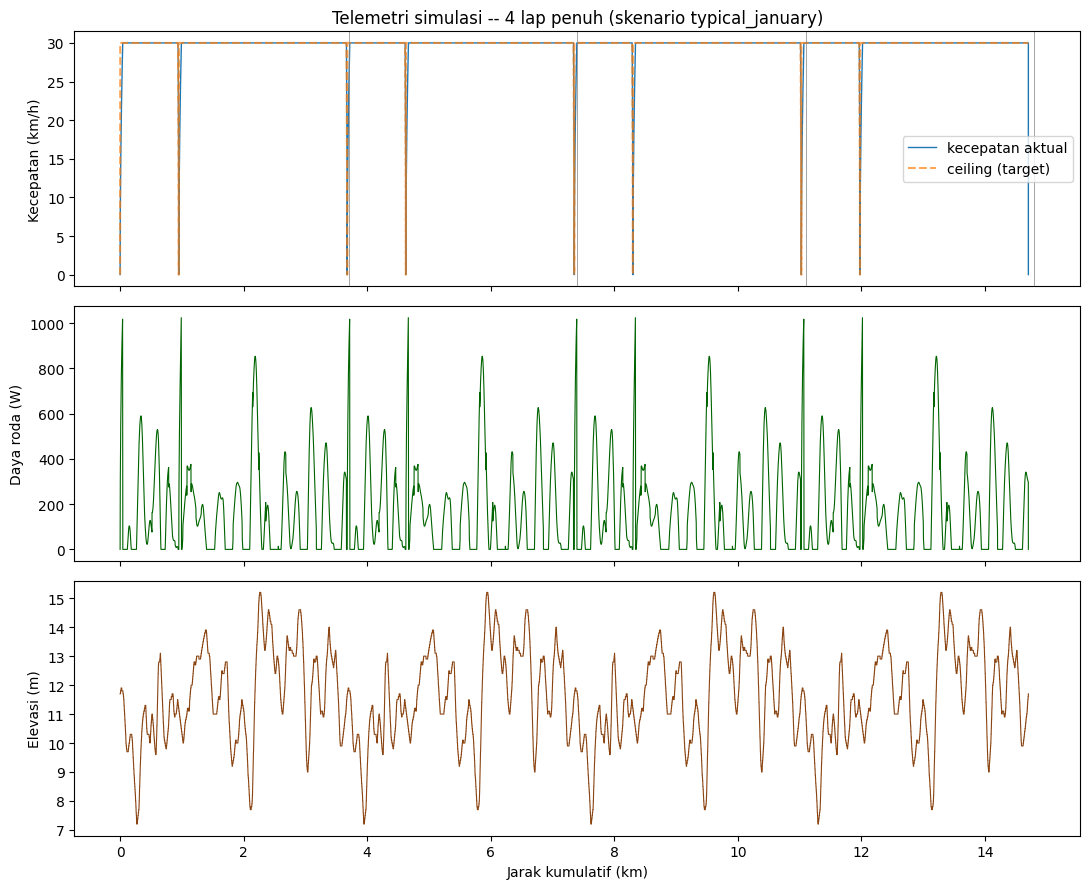

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(telemetry["distance_km"], telemetry["v_kmh"], label="kecepatan aktual", linewidth=1)
axes[0].plot(telemetry["distance_km"], telemetry["v_ceiling_kmh"], label="ceiling (target)", linestyle="--", alpha=0.7)
for lap in range(1, config.TOTAL_LAPS + 1):
    axes[0].axvline(lap * config.LAP_DISTANCE_KM, color="gray", linewidth=0.5)
axes[0].set_ylabel("Kecepatan (km/h)")
axes[0].set_title("Telemetri simulasi -- 4 lap penuh (skenario typical_january)")
axes[0].legend()

axes[1].plot(telemetry["distance_km"], telemetry["p_wheel_w"], linewidth=0.8, color="darkgreen")
axes[1].set_ylabel("Daya roda (W)")

axes[2].plot(telemetry["distance_km"], telemetry["altitude_m"], linewidth=0.8, color="saddlebrown")
axes[2].set_ylabel("Elevasi (m)")
axes[2].set_xlabel("Jarak kumulatif (km)")

plt.tight_layout()
plt.show()

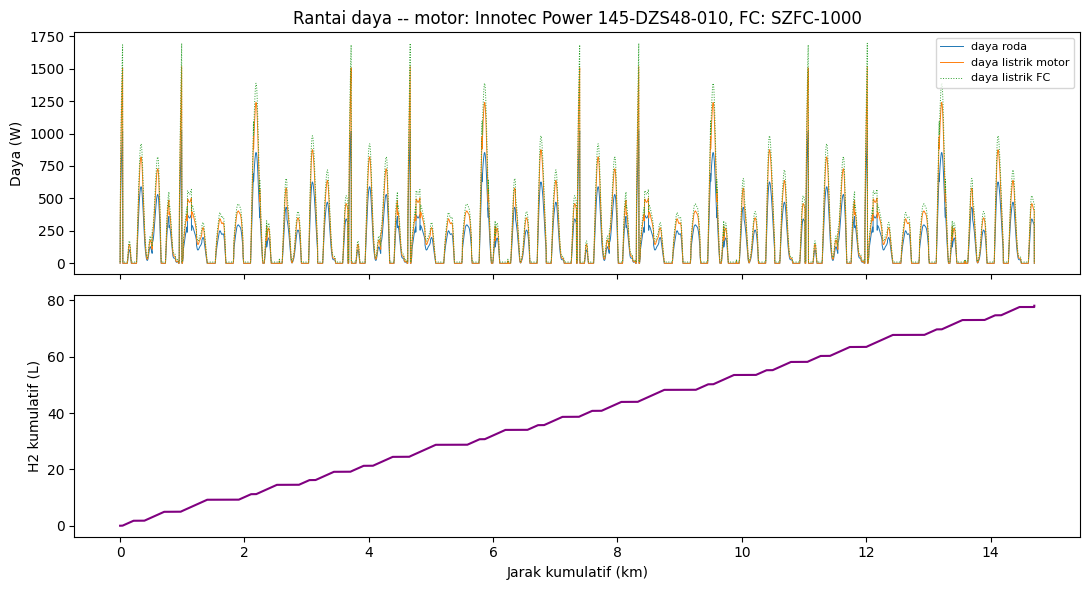

Total H2: 78.13 L -- skor: 188.2 km/m3 H2


In [8]:
# Rantai daya: roda -> mekanik motor -> listrik motor -> listrik FC -> H2 kumulatif
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axes[0].plot(telemetry["distance_km"], telemetry["p_wheel_w"], label="daya roda", linewidth=0.7)
axes[0].plot(telemetry["distance_km"], telemetry["p_motor_elec_w"], label="daya listrik motor", linewidth=0.7)
axes[0].plot(telemetry["distance_km"], telemetry["p_fc_elec_w"], label="daya listrik FC", linewidth=0.7, linestyle=":")
axes[0].set_ylabel("Daya (W)")
axes[0].set_title(f"Rantai daya -- motor: {config.DEFAULT_MOTOR_NAME}, FC: {config.DEFAULT_FC_NAME}")
axes[0].legend(fontsize=8)

axes[1].plot(telemetry["distance_km"], telemetry["h2_cumulative_m3"] * 1000, color="purple")
axes[1].set_ylabel("H2 kumulatif (L)")
axes[1].set_xlabel("Jarak kumulatif (km)")

plt.tight_layout()
plt.show()

print(f"Total H2: {telemetry['h2_cumulative_m3'].iloc[-1]*1000:.2f} L -- "
      f"skor: {telemetry_mod.h2_score_km_per_m3(telemetry['s_m'].iloc[-1]/1000, telemetry['h2_cumulative_m3'].iloc[-1]):.1f} km/m3 H2")

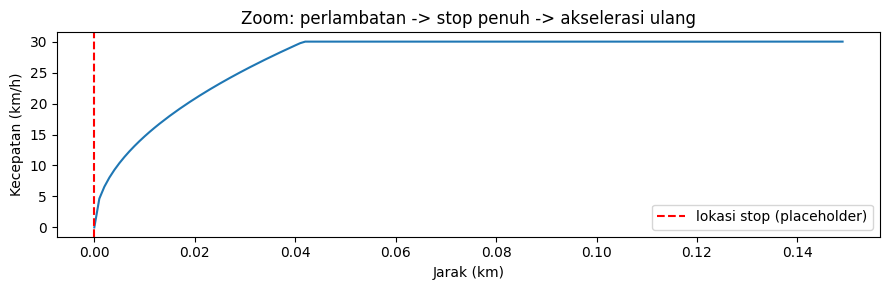

In [9]:
# Zoom ke stop pertama -- cek kecepatan turun mulus ke 0 (bukan instan), lalu naik lagi setelah dwell time
zoom = telemetry[(telemetry["distance_km"] > config.STOP_LOCATIONS_KM[0] - 0.15) &
                  (telemetry["distance_km"] < config.STOP_LOCATIONS_KM[0] + 0.15)]

plt.figure(figsize=(9, 3))
plt.plot(zoom["distance_km"], zoom["v_kmh"])
plt.axvline(config.STOP_LOCATIONS_KM[0], color="red", linestyle="--", label="lokasi stop (placeholder)")
plt.ylabel("Kecepatan (km/h)")
plt.xlabel("Jarak (km)")
plt.title("Zoom: perlambatan -> stop penuh -> akselerasi ulang")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Benchmark DP (batas atas efisiensi fisik)

Strategi crude di atas heuristik sederhana, bukan optimal. `optimize_dp.py` menghitung **batas atas efisiensi yang mungkin dicapai** lewat backward induction di grid (jarak x kecepatan), meminimalkan H2 dengan batas waktu Pasal 226 (ditangani lewat "harga waktu" lambda yang dicari via bisection sampai total waktu pas di bawah 35 menit). Trace-nya optimal-fisik, bukan sesuatu yang bisa diikuti driver secara presisi -- itu tugas GA di bawah.

**Penting:** pola gas-glide TIDAK di-hardcode -- DP hanya diberi fisika + kurva efisiensi motor/FC + batas waktu, dan pola **pulse-and-glide muncul sendiri** sebagai solusi optimal. Validasi independen bahwa intuisi gas/glide benar untuk kendaraan ini.

*Catatan kejujuran model:* puncak pulse optimal (~50 km/h) sebagian didorong efisiensi motor yang dimodelkan sangat buruk di beban rendah (interpolasi linear lewat titik datasheet (0 W, 0%)) -- tinjau ulang begitu ada data efisiensi motor beban-rendah sebenarnya.

**Update (2026-07-21):** `optimize_dp.py` (dan `optimize_ga.py`/`optimize_pso.py`/`optimize_cma.py`) sekarang defaultnya jalan di atas **QP racing line** (`track.build_racing_line_profile()`, Bagian 7 di bawah), bukan backbone GPS mentah yang divisualisasikan di Bagian 2 -- lap lebih pendek + kurva per-titik asli menggantikan radius konstan per zona tikungan dari `turns.csv`. DP di sel berikut karena itu jalan di track yang berbeda dari `profile` yang divisualisasikan di atas; lihat `notebooks/Racing_Line_Strategy_Comparison.ipynb` untuk perbandingan before/after lengkap (DP tervalidasi lebih baik di racing line: +7.3% setelah fix motor efficiency 2026-07-21, lihat Bagian 7 di bawah).

In [10]:
from digital_twin import optimize_dp

dp_result = optimize_dp.run_dp_benchmark(scenario_name="typical_january", save=True)
dp_tel = dp_result["telemetry"]
dp_accessory_l = telemetry_mod.accessory_h2_equivalent_m3(dp_result["accessory_energy_j"]) * 1000

comparison = pd.DataFrame([
    {"strategi": "Crude (constant-speed)", "H2 flow-meter (L)": round(total_h2_m3 * 1000, 2),
     "aksesori (L eq.)": round(accessory_h2_equiv_l, 2), "waktu (menit)": round(total_time_s / 60, 2),
     "skor Pasal 54e (km/m3)": round(h2_score, 1)},
    {"strategi": "DP benchmark (optimal-fisik)", "H2 flow-meter (L)": round(dp_result["h2_m3"] * 1000, 2),
     "aksesori (L eq.)": round(dp_accessory_l, 2), "waktu (menit)": round(dp_result["time_total_min"], 2),
     "skor Pasal 54e (km/m3)": round(dp_result["score_km_per_m3"], 1)},
])
print(f"Penghematan H2 DP vs crude: {(1 - dp_result['h2_m3'] / total_h2_m3) * 100:.1f}%")
comparison

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


Penghematan H2 DP vs crude: 36.4%


,strategi,H2 flow-meter (L),aksesori (L eq.),waktu (menit),skor Pasal 54e (km/m3)
0,Crude (constant-speed),78.13,5.05,30.45,176.8
1,DP benchmark (optimal-fisik),49.70,6.31,37.76,258.9


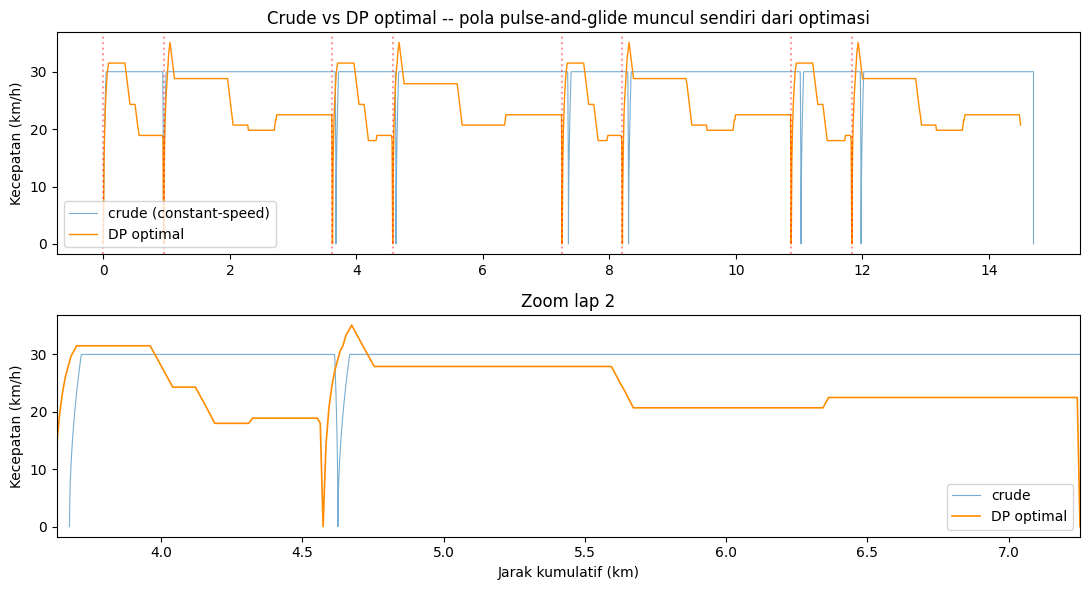

In [11]:
# Bentuk strategi DP: pulse-and-glide terlihat jelas dibanding plateau crude
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)

axes[0].plot(telemetry["distance_km"], telemetry["v_kmh"], linewidth=0.8, alpha=0.6, label="crude (constant-speed)")
axes[0].plot(dp_tel["distance_km"], dp_tel["v_kmh"], linewidth=1.0, color="darkorange", label="DP optimal")
for stop_km in dp_tel.loc[dp_tel["stop_event"], "distance_km"]:
    axes[0].axvline(stop_km, color="red", linestyle=":", alpha=0.4)
axes[0].set_ylabel("Kecepatan (km/h)")
axes[0].set_title("Crude vs DP optimal -- pola pulse-and-glide muncul sendiri dari optimasi")
axes[0].legend()

# zoom 1 lap supaya pola pulse/glide kelihatan detail
lap1_dp = dp_tel[dp_tel["lap"] == 2]
lap1_base = telemetry[telemetry["lap"] == 2]
axes[1].plot(lap1_base["distance_km"], lap1_base["v_kmh"], linewidth=0.8, alpha=0.6, label="crude")
axes[1].plot(lap1_dp["distance_km"], lap1_dp["v_kmh"], linewidth=1.2, color="darkorange", label="DP optimal")
axes[1].set_ylabel("Kecepatan (km/h)")
axes[1].set_xlabel("Jarak kumulatif (km)")
axes[1].set_xlim(lap1_dp["distance_km"].min(), lap1_dp["distance_km"].max())
axes[1].set_title("Zoom lap 2")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Strategi GA (yang bisa dieksekusi driver)

DP di atas itu trace per-titik, tidak bisa diikuti manusia secara presisi. `optimize_ga.py` mencari strategi gas/glide dengan **jauh lebih sedikit parameter** (target kecepatan + threshold coast per segmen lintasan), dievaluasi lewat fungsi `simulate()` yang sama, supaya hasilnya jadi lembar instruksi realistis untuk driver -- bukan kurva kecepatan per-meter.

GA berjalan lama (population x generation x simulate() penuh), jadi dijalankan terpisah lewat `python -m digital_twin.optimize_ga`, bukan di notebook ini. Sel di bawah memuat hasil terakhir dari `data/simulated_telemetry_ga.csv`.

**Update (2026-07-21):** CSV ini sekarang hasil run di **racing line** (bukan backbone), dengan `NUM_SEGMENTS_PER_LAP=30` (naik dari 15) dan `pop_size=50, n_gen=40` (naik dari 20/30) -- keduanya sekarang default baru di `optimize_ga.py`. Diagnosis lengkap kenapa GA butuh population lebih besar (bukan cuma segmen lebih banyak) ada di `notebooks/Racing_Line_Strategy_Comparison.ipynb`.

,strategi,H2 flow-meter (L),aksesori (L eq.),waktu (menit),skor Pasal 54e (km/m3)
0,Crude (constant-speed),78.13,5.05,30.45,176.8
1,DP benchmark (optimal-fisik),49.70,6.31,37.76,258.9
2,GA (driver-executable),60.73,5.81,34.92,218.0


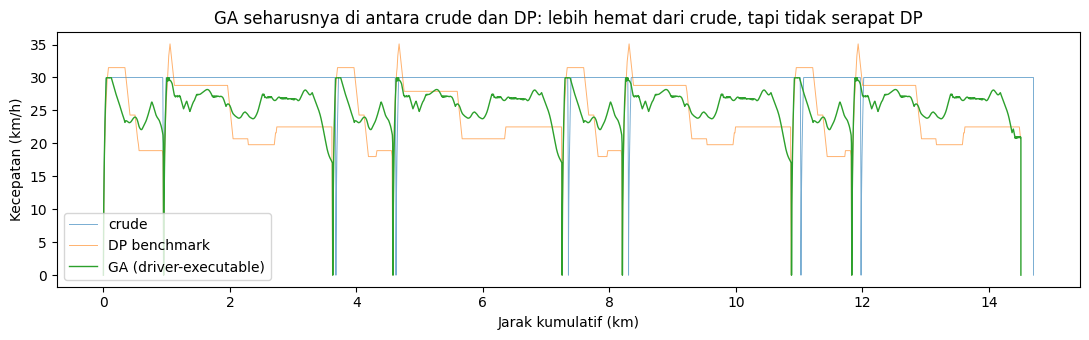

In [12]:
import os

GA_CSV = "data/simulated_telemetry_ga.csv"
REQUIRED_COLS = {"t_s", "s_m", "h2_cumulative_m3", "accessory_energy_cumulative_j"}

ga_tel = pd.read_csv(GA_CSV) if os.path.exists(GA_CSV) else None
ga_ready = ga_tel is not None and REQUIRED_COLS.issubset(ga_tel.columns)

if ga_ready:
    ga_time_s = ga_tel["t_s"].iloc[-1]
    ga_dist_km = ga_tel["s_m"].iloc[-1] / 1000.0
    ga_h2_m3 = ga_tel["h2_cumulative_m3"].iloc[-1]
    ga_accessory_j = ga_tel["accessory_energy_cumulative_j"].iloc[-1]
    ga_accessory_l = telemetry_mod.accessory_h2_equivalent_m3(ga_accessory_j) * 1000
    ga_score = telemetry_mod.h2_score_km_per_m3(ga_dist_km, ga_h2_m3, accessory_energy_j=ga_accessory_j)

    comparison_full = pd.concat([comparison, pd.DataFrame([
        {"strategi": "GA (driver-executable)", "H2 flow-meter (L)": round(ga_h2_m3 * 1000, 2),
         "aksesori (L eq.)": round(ga_accessory_l, 2), "waktu (menit)": round(ga_time_s / 60, 2),
         "skor Pasal 54e (km/m3)": round(ga_score, 1)},
    ])], ignore_index=True)
    display(comparison_full)

    plt.figure(figsize=(11, 3.5))
    plt.plot(telemetry["distance_km"], telemetry["v_kmh"], label="crude", linewidth=0.7, alpha=0.6)
    plt.plot(dp_tel["distance_km"], dp_tel["v_kmh"], label="DP benchmark", linewidth=0.7, alpha=0.6)
    plt.plot(ga_tel["distance_km"], ga_tel["v_kmh"], label="GA (driver-executable)", linewidth=1.0)
    plt.xlabel("Jarak kumulatif (km)")
    plt.ylabel("Kecepatan (km/h)")
    plt.title("GA seharusnya di antara crude dan DP: lebih hemat dari crude, tapi tidak serapat DP")
    plt.legend()
    plt.tight_layout()
    plt.show()
elif ga_tel is not None:
    print(f"{GA_CSV} ada tapi masih dari run LAMA (skema kolom belum termasuk parasitic/aksesori terbaru) "
          f"-- jalankan ulang `python -m digital_twin.optimize_ga` dan re-run sel ini.")
else:
    print(f"{GA_CSV} belum ada -- jalankan `python -m digital_twin.optimize_ga` dulu (~30 menit).")

## 6a. Strategi Fuzzy (rulebook terrain — dapat dieksekusi driver)

Alternatif dari pencarian evolusioner GA: kontroler **fuzzy logic** membaca kemiringan jalan di depan dan menerjemahkannya ke setpoint gas/glide lewat aturan yang bisa dibaca manusia — *menanjak → target lebih pelan (jangan boros H2 lawan gravitasi); datar → cruise ekonomis; menurun → matikan motor lebih awal, meluncur (kecepatan gratis dari gravitasi)*. Tidak ada optimasi per-run yang mahal — cukup ~20 baris inferensi fuzzy segitiga + defuzzifikasi centroid. Dievaluasi lewat `simulate()` yang sama, di **racing line** + **dua motor** (BLDC 650W akselerasi + BG 42x30 dCore cruise) + **SZFC-1000**. Knob-nya di-tuning otomatis untuk run paling efisien yang masih feasible (≤ 35 menit, 0 pelanggaran). Modul: `digital_twin/fuzzy_strategy.py`.

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


Fuzzy: skor 264.0 km/m3 | waktu 34.77 mnt | H2 49.17 L | pelanggaran 0


,strategi,H2 flow-meter (L),aksesori (L eq.),waktu (menit),skor Pasal 54e (km/m3)
0,Crude (constant-speed),78.13,5.05,30.45,176.8
1,DP benchmark (optimal-fisik),49.70,6.31,37.76,258.9
2,GA (driver-executable),60.73,5.81,34.92,218.0
3,Fuzzy (rulebook terrain),49.17,5.77,34.77,264.0


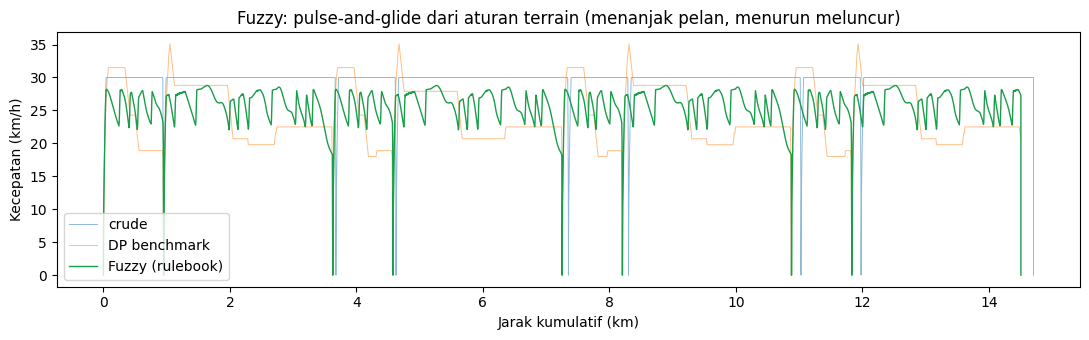

In [13]:
from digital_twin import fuzzy_strategy as fz

scenario = weather_mod.SCENARIOS["typical_january"]

# Fuzzy cepat (bukan pencarian evolusioner): tune knob lalu jalankan strategi terbaik yang feasible.
# use_racing_line=True (default) -> track yang sama dengan DP/GA/PSO/CMA-ES.
fuzzy_tel, fuzzy_result = fz.optimize_strategy(scenario_name="typical_january", save=True, verbose=False)
fuzzy_acc_l = telemetry_mod.accessory_h2_equivalent_m3(
    fuzzy_tel["accessory_energy_cumulative_j"].iloc[-1]) * 1000

base_cmp = comparison_full if "comparison_full" in globals() else comparison
comparison_full = pd.concat([base_cmp, pd.DataFrame([
    {"strategi": "Fuzzy (rulebook terrain)", "H2 flow-meter (L)": round(fuzzy_result["h2_l"], 2),
     "aksesori (L eq.)": round(fuzzy_acc_l, 2), "waktu (menit)": round(fuzzy_result["time_min"], 2),
     "skor Pasal 54e (km/m3)": round(fuzzy_result["score_km_per_m3"], 1)},
])], ignore_index=True)
print(f"Fuzzy: skor {fuzzy_result['score_km_per_m3']:.1f} km/m3 | waktu {fuzzy_result['time_min']:.2f} mnt "
      f"| H2 {fuzzy_result['h2_l']:.2f} L | pelanggaran {fuzzy_result['rule_violations']}")
display(comparison_full)

plt.figure(figsize=(11, 3.5))
plt.plot(telemetry["distance_km"], telemetry["v_kmh"], label="crude", linewidth=0.7, alpha=0.5)
plt.plot(dp_tel["distance_km"], dp_tel["v_kmh"], label="DP benchmark", linewidth=0.7, alpha=0.5)
plt.plot(fuzzy_tel["distance_km"], fuzzy_tel["v_kmh"], label="Fuzzy (rulebook)", linewidth=1.0, color="#1a9e4b")
plt.xlabel("Jarak kumulatif (km)"); plt.ylabel("Kecepatan (km/h)")
plt.title("Fuzzy: pulse-and-glide dari aturan terrain (menanjak pelan, menurun meluncur)")
plt.legend(); plt.tight_layout(); plt.show()


## 6b. Strategi MPC (receding-horizon — kontrol adaptif real-time)

Berbeda dari GA/PSO/CMA-ES (optimasi *offline* yang menghasilkan tabel per-segmen) dan DP (trace per-titik), **Model Predictive Control** memutuskan tiap langkah secara *live*: melihat horizon N langkah ke depan, meng-enumerasi kandidat kecepatan, me-roll-out tiap kandidat lewat fisika twin yang **persis sama** (`simulate.step()`), lalu memakai kecepatan yang rollout-nya paling hemat H2 (dengan batas ceiling keselamatan + budget waktu Pasal 226). Kunci efisiensinya: saat perlu melambat ia **meluncur (motor mati), bukan mengerem** — sama seperti gas/glide GA, tapi diputuskan real-time. Jalan di **racing line** + **dua motor** + **SZFC-1000**; blueprint `MPC_SPEC.md`, implementasi `digital_twin/mpc.py`.

*Catatan: `mpc.optimize_strategy()` kini defaultnya dua-motor + racing line — sebelumnya keliru jalan single-motor di backbone GPS mentah, jadi tidak mencerminkan konfigurasi hardware nyata.*

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)


MPC: skor 253.1 km/m3 | waktu 34.49 mnt | H2 51.58 L | pelanggaran 0


,strategi,H2 flow-meter (L),aksesori (L eq.),waktu (menit),skor Pasal 54e (km/m3)
0,Crude (constant-speed),78.13,5.05,30.45,176.8
1,DP benchmark (optimal-fisik),49.70,6.31,37.76,258.9
2,GA (driver-executable),60.73,5.81,34.92,218.0
3,Fuzzy (rulebook terrain),49.17,5.77,34.77,264.0
4,MPC (receding-horizon),51.58,5.72,34.49,253.1


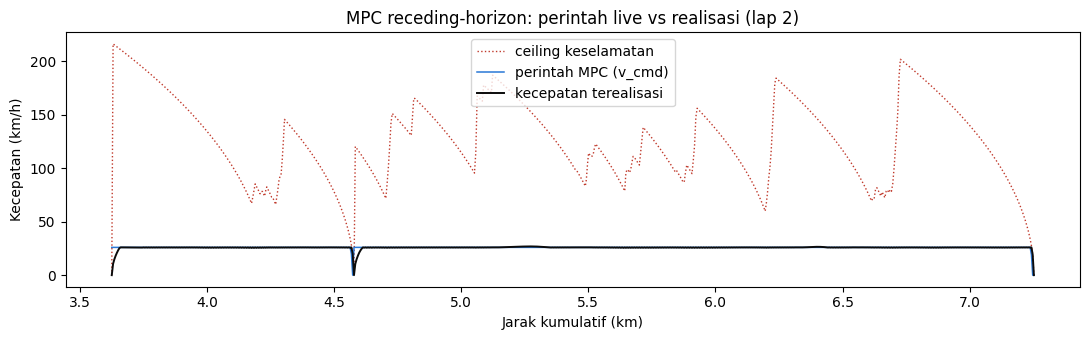

In [14]:
from digital_twin import mpc as mpc_mod

# Konfigurasi hardware nyata: dua motor + SZFC-1000, di racing line (backbone yang sama dgn GA/DP).
prof_rl = track_mod.build_racing_line_profile(save=False)
full_rl = sim_mod.build_full_attempt_track(prof_rl)
accel_m = powertrain.load_motors()[config.ACCEL_MOTOR_NAME]
cruise_m = powertrain.load_motors()[config.CRUISE_MOTOR_NAME]
cruise_converter = powertrain.load_converters()[config.CRUISE_CONVERTER_NAME]  # DC-DC (Querom) -- konsisten dgn notebooks/mpc

# theta = hyperparameter yang (di notebook mpc_analyze) disapu; floor v_min=26 km/h adalah pilihan
# paling efisien yang tetap feasible. alpha_drv=0 -> setpoint MPC murni (layer driver-aware nonaktif).
mpc_theta = dict(config.MPC_THETA_DEFAULT)
mpc_theta.update({"w_h2": 6000.0, "w_time": 2.0, "w_track": 60.0, "w_du": 2.0,
                  "alpha_drv": 0.0, "v_min_kmh": 26.0, "v_max_kmh": 30.0, "horizon_n": 20})
mpc_tel = mpc_mod.run_closed_loop(full_rl, scenario, None, fc, theta=mpc_theta, cruise_converter=cruise_converter,
                                  accel_motor=accel_m, cruise_motor=cruise_m, n_candidates=9)
mpc_result = mpc_mod.score_telemetry(mpc_tel)
mpc_acc_l = telemetry_mod.accessory_h2_equivalent_m3(
    mpc_tel["accessory_energy_cumulative_j"].iloc[-1]) * 1000

comparison_full = pd.concat([comparison_full, pd.DataFrame([
    {"strategi": "MPC (receding-horizon)", "H2 flow-meter (L)": round(mpc_result["h2_l"], 2),
     "aksesori (L eq.)": round(mpc_acc_l, 2), "waktu (menit)": round(mpc_result["time_min"], 2),
     "skor Pasal 54e (km/m3)": round(mpc_result["score_km_per_m3"], 1)},
])], ignore_index=True)
print(f"MPC: skor {mpc_result['score_km_per_m3']:.1f} km/m3 | waktu {mpc_result['time_min']:.2f} mnt "
      f"| H2 {mpc_result['h2_l']:.2f} L | pelanggaran {mpc_result['rule_violations']}")
display(comparison_full)

# MPC bersifat live: perintah tiap langkah vs kecepatan terealisasi (satu lap contoh)
lap2 = mpc_tel[mpc_tel["lap"] == 2]
plt.figure(figsize=(11, 3.5))
plt.plot(lap2["distance_km"], lap2["v_ceiling_kmh"], label="ceiling keselamatan", color="#c0392b", ls=":", lw=1.0)
plt.plot(lap2["distance_km"], lap2["v_cmd_mpc"], label="perintah MPC (v_cmd)", color="#2a78d6", lw=1.1)
plt.plot(lap2["distance_km"], lap2["v_kmh"], label="kecepatan terealisasi", color="#0b0b0b", lw=1.4)
plt.xlabel("Jarak kumulatif (km)"); plt.ylabel("Kecepatan (km/h)")
plt.title("MPC receding-horizon: perintah live vs realisasi (lap 2)")
plt.legend(); plt.tight_layout(); plt.show()


## 7. Driving Line Optimal & Dampaknya

Lebar trek sekarang terukur per titik (digitasi citra satelit -- detail lengkap & QA di `Track_Analysis.ipynb` Bagian 7-8), jadi kita bisa optimasi **garis mengemudi**: jalur terpendek di dalam koridor drivable (shortest-path QP ala TUM, `digital_twin/racing_line.py`), dengan clearance setengah lebar kendaraan + margin, dan regularizer kelengkungan.

Kenapa jalur terpendek = optimal-energi di SEM: rolling resistance dan aero sama-sama proporsional jarak tempuh, bukan waktu.

**Update (2026-07-21) -- ini sekarang benar-benar terpakai, bukan cuma estimasi kasar:** `track.py` punya `build_racing_line_profile()` yang menggantikan backbone GPS sebagai input DP/GA/PSO/CMA-ES (lihat catatan di Bagian 5-6 di atas). Dampak H2 aktual (bukan ekstrapolasi proporsional-jarak di bawah) tervalidasi lewat `notebooks/Racing_Line_Strategy_Comparison.ipynb`: DP +7.3% (setelah fix motor-efficiency 2026-07-21). GA/PSO/CMA-ES angka final ada di tabel Bagian 7, tapi backbone-nya tidak di-re-run dengan fix yang sama jadi tidak dibandingkan langsung di sini -- detail di Racing_Line_Strategy_Comparison.ipynb.

In [15]:
rl = pd.read_csv("data/racing_line.csv")
edges = pd.read_csv("data/track_edges_imagery.csv")

seg = np.hypot(np.diff(np.append(rl.x_m, rl.x_m.iloc[0])),
               np.diff(np.append(rl.y_m, rl.y_m.iloc[0])))
rl_len = float(seg.sum())
center_len = float(edges.station_new_m.iloc[-1] + 3)  # + seam penutup loop
saved_per_lap = center_len - rl_len
saved_attempt = saved_per_lap * config.TOTAL_LAPS

print("=" * 62)
print("  DRIVING LINE OPTIMAL -- shortest path dalam koridor terukur")
print("=" * 62)
print(f"  Panjang centerline terukur : {center_len:7.1f} m/lap")
print(f"  Panjang driving line       : {rl_len:7.1f} m/lap")
print(f"  Hemat jarak                : {saved_per_lap:7.1f} m/lap  "
      f"({saved_attempt:.0f} m per attempt {config.TOTAL_LAPS} lap, "
      f"~{saved_per_lap / center_len * 100:.1f}%)")
print(f"  Radius min di garis        : {rl.radius_m.min():7.1f} m   (batas kendaraan 6 m, Art. 47)")
print(f"  V_safe min di garis        : {rl.v_safe_kmh.min():7.1f} km/h (di atas puncak pulse DP ~50)")
print()
print("  PERBANDINGAN STRATEGI FINAL (2026-07-24) -- controller terpadu, cap 30 km/h, hybrid FC+superkap:")
impact = pd.DataFrame([
    {"algoritma": "GA",     "controller": "efficiency",       "cap km/h": 30, "waktu (mnt)": 34.88, "skor (km/m3)": 280.4},
    {"algoritma": "Fuzzy",  "controller": "efficiency",       "cap km/h": 30, "waktu (mnt)": 34.67, "skor (km/m3)": 265.0},
    {"algoritma": "MPC",    "controller": "efficiency",       "cap km/h": 30, "waktu (mnt)": 34.38, "skor (km/m3)": 253.3},
    {"algoritma": "PSO",    "controller": "rule",             "cap km/h": 30, "waktu (mnt)": 34.98, "skor (km/m3)": 221.2},
    {"algoritma": "CMA-ES", "controller": "rule (warm-start)","cap km/h": 30, "waktu (mnt)": 34.72, "skor (km/m3)": 207.2},
])
display(impact)
print()
print("  DP benchmark (dua-motor, rule, TANPA batas waktu 35 mnt): 258.9 km/m3 @ 37.76 mnt --")
print("  referensi batas atas fisik, bukan strategi yang dilombakan (melewati batas waktu).")
print()
print("  efficiency vs rule:")
print("   - rule       : controller sederhana -- motor akselerasi HANYA saat relaunch dari stop atau")
print("                  menanjak; selebihnya motor cruise. ~15 perpindahan motor, konservatif.")
print("   - efficiency : pilih motor PALING EFISIEN untuk tiap titik operasi (kurva efisiensi kedua")
print("                  motor beda). Skor lebih tinggi, tapi ratusan perpindahan -- tiap perpindahan")
print("                  bayar penalti servo 0.5s (sudah dimodelkan). CMA-ES tak bisa capai region")
print("                  feasible efficiency di cap 30 km/h, jadi tetap di rule (di-warm-start).")
print()
print("  LULUS aturan SEM (semua strategi): 14.50 km / 4 lap / 2 titik stop-and-go (berhenti penuh v=0) /")
print("  <=35 mnt / 0 pelanggaran / Pasal 56c superkap V_akhir>=V_awal=45.54V / kecepatan komando <=30 km/h.")


  DRIVING LINE OPTIMAL -- shortest path dalam koridor terukur
  Panjang centerline terukur :  3685.2 m/lap
  Panjang driving line       :  3626.5 m/lap
  Hemat jarak                :    58.7 m/lap  (235 m per attempt 4 lap, ~1.6%)
  Radius min di garis        :    33.2 m   (batas kendaraan 6 m, Art. 47)
  V_safe min di garis        :    59.9 km/h (di atas puncak pulse DP ~50)

  PERBANDINGAN STRATEGI FINAL (2026-07-24) -- controller terpadu, cap 30 km/h, hybrid FC+superkap:


,algoritma,controller,cap km/h,waktu (mnt),skor (km/m3)
0,GA,efficiency,30,34.88,280.4
1,Fuzzy,efficiency,30,34.67,265.0
2,MPC,efficiency,30,34.38,253.3
3,PSO,rule,30,34.98,221.2
4,CMA-ES,rule (warm-start),30,34.72,207.2



  DP benchmark (dua-motor, rule, TANPA batas waktu 35 mnt): 258.9 km/m3 @ 37.76 mnt --
  referensi batas atas fisik, bukan strategi yang dilombakan (melewati batas waktu).

  efficiency vs rule:
   - rule       : controller sederhana -- motor akselerasi HANYA saat relaunch dari stop atau
                  menanjak; selebihnya motor cruise. ~15 perpindahan motor, konservatif.
   - efficiency : pilih motor PALING EFISIEN untuk tiap titik operasi (kurva efisiensi kedua
                  motor beda). Skor lebih tinggi, tapi ratusan perpindahan -- tiap perpindahan
                  bayar penalti servo 0.5s (sudah dimodelkan). CMA-ES tak bisa capai region
                  feasible efficiency di cap 30 km/h, jadi tetap di rule (di-warm-start).

  LULUS aturan SEM (semua strategi): 14.50 km / 4 lap / 2 titik stop-and-go (berhenti penuh v=0) /
  <=35 mnt / 0 pelanggaran / Pasal 56c superkap V_akhir>=V_awal=45.54V / kecepatan komando <=30 km/h.


## 8. Ringkasan & langkah selanjutnya

**Baru (2026-07-24) -- sistem energi hybrid, cap driveable 30 km/h, controller terpadu, sweep cuaca:**
- **Sistem energi hybrid**: Fuel Cell SZFC-1000 dijaga bang-bang di titik efisien **558 W (62%, band 500-570 W)** PARALEL dengan superkapasitor 3-seri Maxwell BMOD0058 (buffer arus/transien) -> DC-DC converter (Querom DDL3050-48). H2 ditagih via **joulemeter Pasal 54e** `(E_fc/eff)/(NCV x rho)` pada energi FC bang-bang (bukan permintaan bus mentah) -- selisih ~2-3% adalah kerja load-leveling superkapasitor.
- **Pasal 56c(iii)**: superkapasitor berakhir di SOC >= awal (V_akhir = V_awal = **45.54 V**; tak pernah overcharge <48 V, tak pernah over-discharge >24 V). Energi recharge diserap idle-FC (0 penalti waktu).
- **Cap kecepatan 30 km/h** (titik desain cruise Urban Concept) supaya pulse-and-glide realistis untuk driver: perpindahan motor otomatis firmware; **driver hanya mengikuti setpoint kecepatan <=30 km/h**.
- **Controller terpadu untuk perbandingan adil**: GA/Fuzzy/MPC di `efficiency`, CMA-ES di `rule` (CMA-ES tak bisa capai region feasible `efficiency` di cap 30 km/h; di-warm-start supaya feasible).
- **RANKING FINAL (typical_january)**: **GA 280.4 > Fuzzy 265.0 > MPC 253.3 > CMA-ES 207.2** km/m3 -- semua <=35 mnt, 0 pelanggaran.
- **Sweep cuaca (calm/typical/strong)**: notebook per-algoritma di `notebooks/{ga,cma,fuzzy,mpc}/{calm,typical,strong}/`. Skor turun monoton **calm > typical > strong** (mis. GA 284.5 / 280.4 / 259.3) -- fisika headwind benar.
- **Verifikasi aturan SEM**: 14.50 km, 4 lap, 2 titik stop-and-go (berhenti penuh v=0 tiap lap), <35 mnt, 0 pelanggaran cornering/ceiling; daya motor, rating DC-DC converter, dan jendela tegangan superkapasitor [24,48] V semuanya dalam batas.

**Yang sudah terbukti dari pipeline ini:**
- Total jarak/waktu/rata-rata kecepatan konsisten Pasal 226; jumlah stop konsisten Pasal 227.
- Powertrain pakai kurva motor/FC nyata (digitized datasheet), CFD CdA nyata dari tim VD, plus koreksi konservatif: parasitic FC (Pasal 65), rugi thermal buffer, cornering scrub.
- Skor mengikuti rumus Pasal 54e persis (flow-meter H2 + ekuivalen baterai aksesori joulemeter).

**Yang masih placeholder (ditag di `config.py`):** gear ratio, Crr, koefisien scrub, beban aksesori, lokasi stop, margin driving line.

**Catatan histori (pra-2026-07-24, sebelum cap 30 + hybrid + controller terpadu):** MPC 278.5 / GA 272.5 / PSO 268.2 / CMA-ES 262.6 / Fuzzy 256.3 (efficiency-mode tanpa cap kecepatan, tanpa sistem hybrid). Perbedaan utama: cap 30 km/h + penagihan H2 pada energi FC bang-bang menurunkan skor absolut tapi membuat strategi realistis & patuh Pasal 56c. Lihat `notebooks/Racing_Line_Strategy_Comparison.ipynb` untuk histori fixes.